In [1]:
#1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

In [2]:
#2. Load Dataset
df = pd.read_csv("superstore.csv")

In [3]:
#3. Preview Dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [4]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10795,Yes,US-2018-147886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10796,Yes,US-2018-147998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10797,Yes,US-2018-151127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10798,Yes,US-2018-155999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10799,Yes,US-2018-155999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#4. Dataset Information
print(df.shape)
df.info()


(10800, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64

In [6]:
#5. Check Missing Values
df.isnull().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

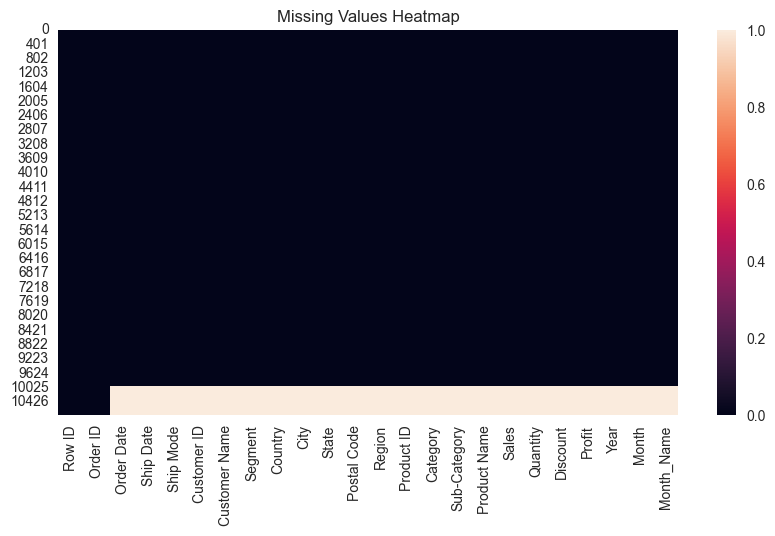

In [24]:
#Visualize Missing Values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=True)
plt.title("Missing Values Heatmap")
plt.show()
#you can drop also 

In [8]:
##### 6. Statistical Summary
df.describe()


,Postal Code,Sales,Quantity,Discount,Profit
count,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55245.233297,229.858001,3.789574,0.156203,28.656896
std,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
#7. Convert Date Column
df['Order Date'] = pd.to_datetime(df['Order Date'])
#Extract year/month:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()


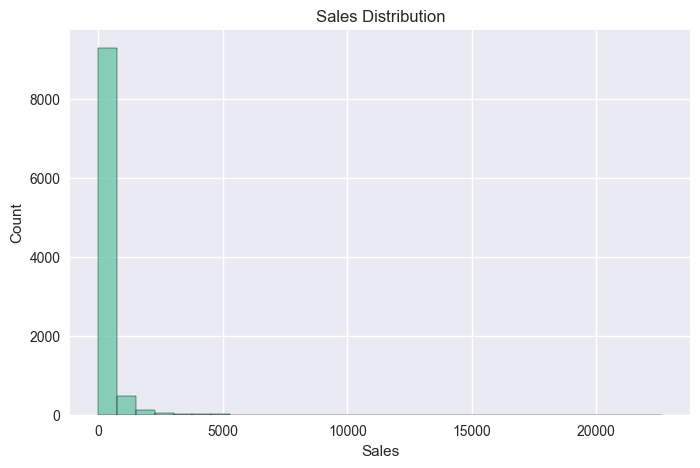

In [27]:
#8. Univariate Analysis
#Sales Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.show()
#Insight
#•	Most orders are small
#•	Few orders generate very high sales

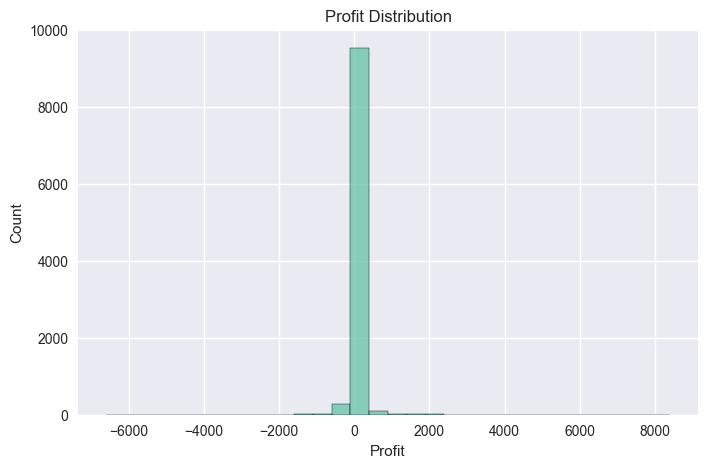

In [28]:
#Profit Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], bins=30)
plt.title("Profit Distribution")
plt.show()


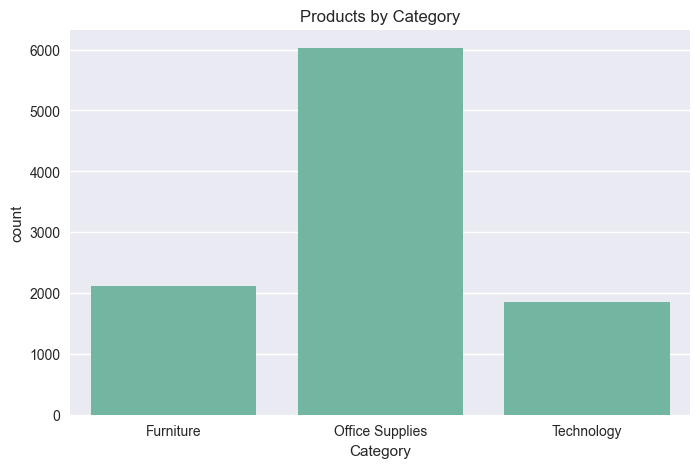

In [12]:
#Category Analysis
plt.figure(figsize=(8,5))
sns.countplot(x='Category', data=df)
plt.title("Products by Category")
plt.show()


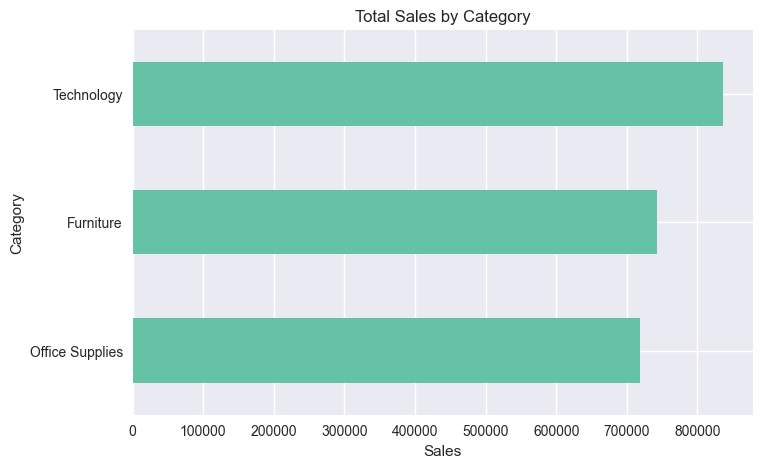

In [13]:
#9. Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

category_sales.plot(kind='barh', figsize=(8,5))
plt.title("Total Sales by Category")
plt.xlabel("Sales")
plt.show()


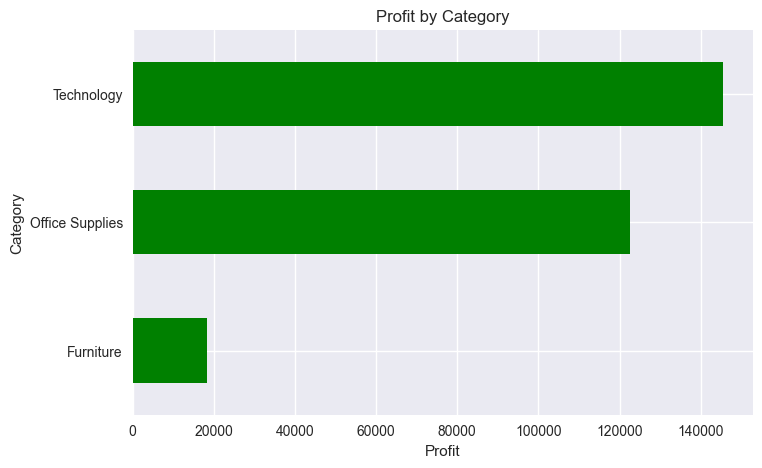

In [14]:
#10. Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().sort_values()

category_profit.plot(kind='barh', color='green', figsize=(8,5))
plt.title("Profit by Category")
plt.xlabel("Profit")
plt.show()


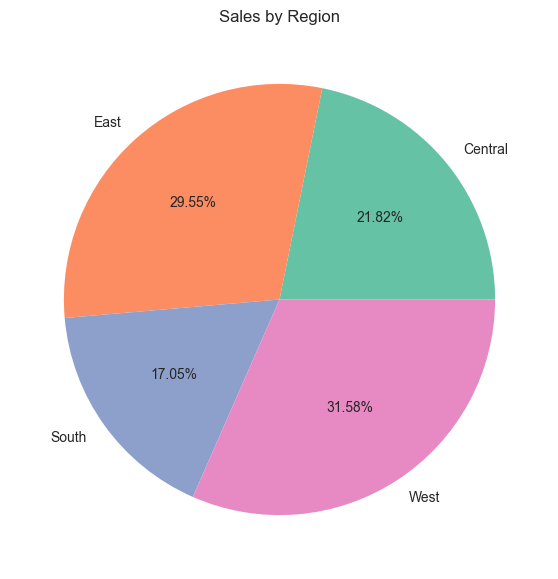

In [15]:
#11. Regional Analysis
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='pie', autopct='%1.2f%%', figsize=(7,7))
plt.title("Sales by Region")
plt.ylabel("")
plt.show()


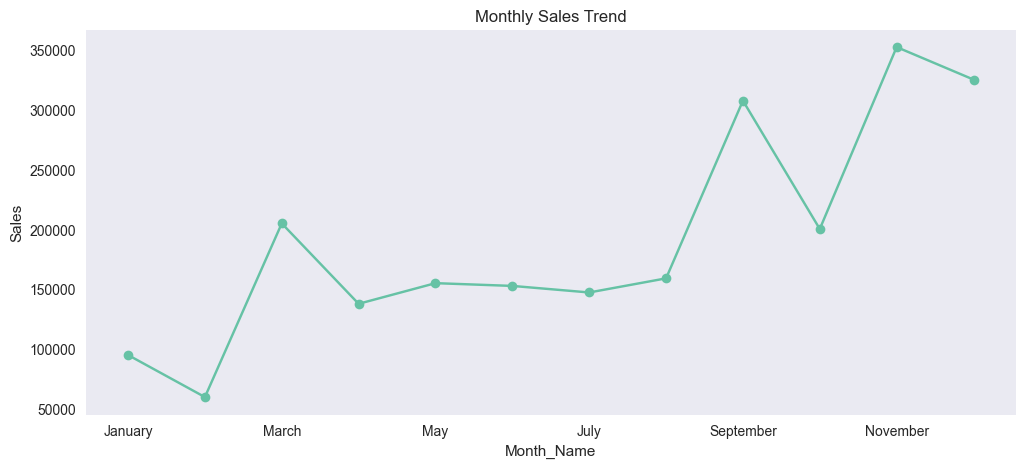

In [16]:
#12. Monthly Sales Trend
monthly_sales = df.groupby('Month_Name')['Sales'].sum()

monthly_sales = monthly_sales.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.grid()
plt.show()


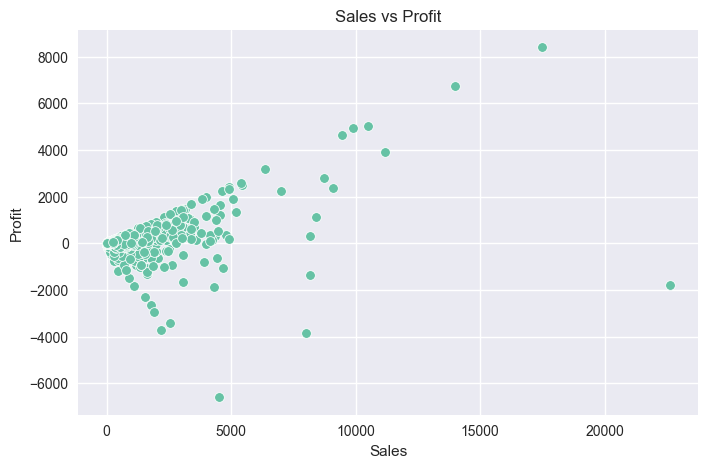

In [17]:
#13. Sales vs Profit
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()
#Insight
#•	High sales do not always mean high profit
#•	Some high-sales orders produce losses


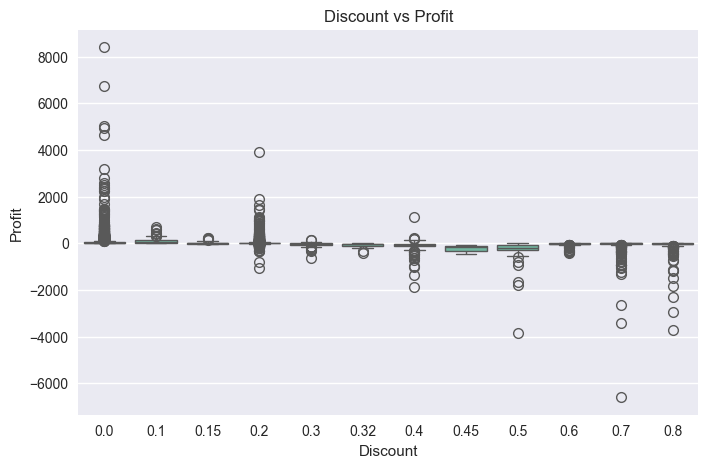

In [18]:
#14. Discount Impact on Profit
plt.figure(figsize=(8,5))
sns.boxplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()
#Insight
#•	Heavy discounts reduce profitability


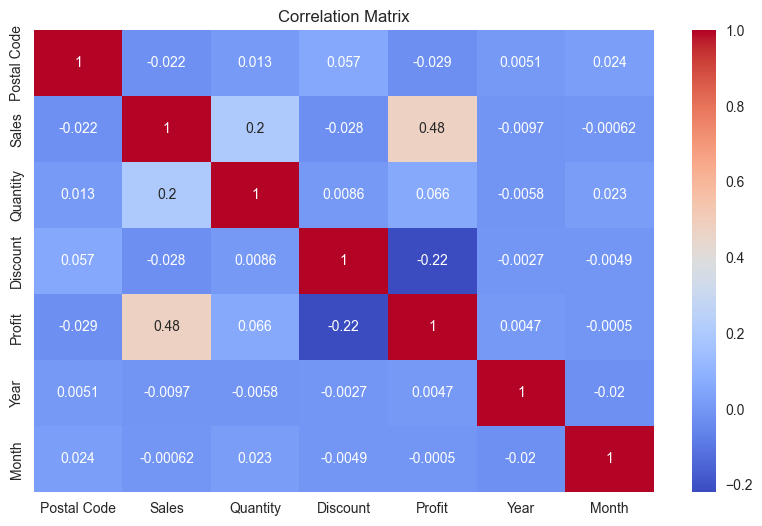

In [19]:
#15. Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


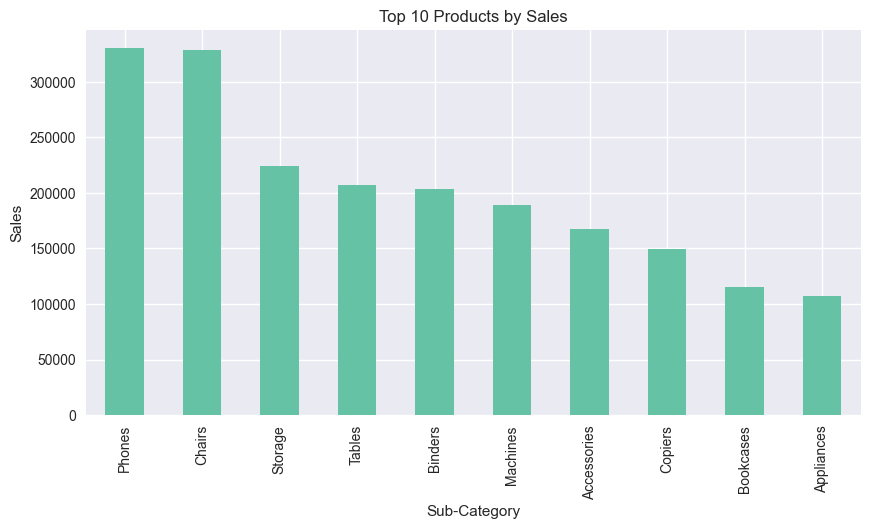

In [20]:

#16. Top 10 Products by Sales
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")
plt.show()


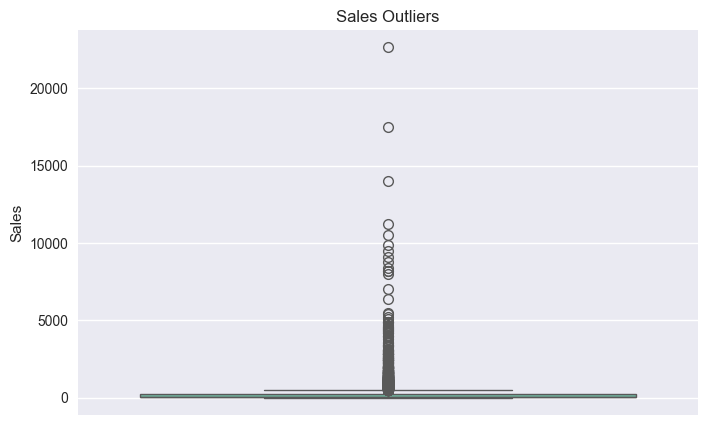

In [21]:
#17. Outlier Detection
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Sales'])
plt.title("Sales Outliers")
plt.show()

In [ ]:
'''
1. Business Insights
Key Findings
1. Technology category generates highest sales
2. Large discounts reduce profit significantly
3. Some regions outperform others consistently
4. Seasonal sales spikes occur near year-end
5. Certain products generate high revenue but low profit

2. Recommendations
•	Reduce excessive discounts
•	Promote high-profit products
•	Improve underperforming regions
•	Focus marketing during peak months
•	Analyze loss-making products

3. Save Cleaned Dataset
df.to_csv("cleaned_sales_data.csv", index=False)

4.Full Notebook Structure
A professional EDA notebook usually follows:
1. Problem Statement
2. Import Libraries
3. Load Dataset
4. Data Cleaning
5. Missing Values
6. Univariate Analysis
7. Bivariate Analysis
8. Multivariate Analysis
9. Outlier Detection
10. Correlation Analysis
11. Business Insights
12. Recommendations
13. Conclusion

Optional Improvements
You can enhance this EDA with:
•	Interactive charts using Plotly
•	Dashboard creation using Power BI
•	Automated reports using ydata-profiling
•	SQL integration
•	Machine learning predictions

Common Interview Questions from This EDA
1.	How did you handle missing values?
2.	Which category was most profitable?
3.	How did discounts affect sales?
4.	What business insights did you discover?
5.	Which visualizations were most useful?
6.	How did you detect outliers?

5.Bonus: Automated EDA Report
Install:
pip install ydata-profiling
Generate report:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Sales EDA Report")

profile.to_file("sales_eda_report.html")
'''